# 02 — H1: does a bare S1/R1 touch predict reversion? (the core, no filters)

**Hypothesis H1.** Stripped of CCI/RSI/EMA/funding, the raw claim of `pivot_cci` is: when an intraday bar's **low pierces S1** (long) or **high pierces R1** (short), price reverts back toward the daily pivot `P`. This notebook tests that claim alone.

**Design (as agreed).**
- Trigger = **`low < S1`** for long / **`high > R1`** for short — exactly the strategy's condition. Causal (low/high known at bar close, pivots known at day open).
- **Fresh-entry dedup:** the event fires only on the *first* bar that enters the zone (prev bar was not in it). No anchor-selection — we take the first touch a real bot would, not the 'best' bar of a cluster (that was the pump-line lookahead).
- **Fixed-horizon** forward returns h ∈ {4, 8, 12, 24} bars (1h TF → up to 1 day), entry at trigger-bar close.
- Pooled across all symbols with **full 2024 coverage** (2025 sealed for OOS). Report mean / median / win% / std / q10.
- **Baseline** = unconditional forward return at *every* bar, same universe/period. A touch number is meaningless without it.
- **Cost** 0.15% round-trip subtracted for the net view.

**Prediction (stated before running).** If a daily pivot level is just 'a price far from the recent mean', the touch edge will be ≈ the plain mean-reversion-after-a-drop edge the `dump` line already owns — i.e. positive on the long/dip side, weak/negative on the short side (alt up-drift), and **no pivot-specific lift** beyond magnitude. If pivots add something, the touch edge should exceed a matched random-dip baseline.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

TF = "1h"
START, END = "2024-01-01", "2025-01-01"   # 2024 only; 2025 sealed
H = 24                                      # max forward horizon (bars)
HORIZONS = [4, 8, 12, 24]
COST = 0.0015                               # 0.15% round-trip

# Universe: every symbol whose parquet covers all of 2024.
def covers_2024(sym):
    lo, hi, n = coverage(sym)
    return lo <= "2024-01" and hi >= "2024-12"

UNIV = [s for s in list_symbols() if covers_2024(s)]
print(f"universe: {len(UNIV)} symbols with full 2024 coverage")
print(UNIV[:12], "...")

universe: 165 symbols with full 2024 coverage
['10000SATSUSDT', '1000BONKUSDT', '1000BTTUSDT', '1000FLOKIUSDT', '1000LUNCUSDT', '1000PEPEUSDT', '1000RATSUSDT', '1000XECUSDT', 'API3USDT', 'ARKUSDT', 'ARPAUSDT', 'ARUSDT'] ...


In [2]:
# ---- event extraction, vectorized per symbol -------------------------------
# For each symbol: find fresh S1-touch (long) and R1-touch (short) bars, collect
# the forward-return PATH (h=1..H) from the trigger-bar close, plus the entry
# headroom to P. Also collect the unconditional baseline path from every bar.

def paths_from(close, idx, H):
    """matrix [len(idx) x H] of simple returns close[i+h]/close[i]-1, h=1..H."""
    c = close
    out = np.full((len(idx), H), np.nan)
    for h in range(1, H + 1):
        ok = idx + h < len(c)
        out[ok, h - 1] = c[idx[ok] + h] / c[idx[ok]] - 1.0
    return out

long_paths, short_paths, base_paths = [], [], []
long_room, short_room = [], []   # (P-entry)/entry headroom at trigger
n_bars_total = 0

for sym in UNIV:
    try:
        df = ohlcv(sym, START, END, TF)
    except Exception:
        continue
    if len(df) < 100:
        continue
    piv = daily_pivots(df)
    close = df["close"].to_numpy()
    low, high = df["low"].to_numpy(), df["high"].to_numpy()
    s1, r1, p = piv["s1"].to_numpy(), piv["r1"].to_numpy(), piv["p"].to_numpy()
    n_bars_total += len(df)

    in_long = low < s1
    in_short = high > r1
    # fresh entry into the zone: in-zone now, not in-zone previous bar
    fresh_long = np.where(in_long & ~np.r_[False, in_long[:-1]])[0]
    fresh_short = np.where(in_short & ~np.r_[False, in_short[:-1]])[0]
    # drop events too close to the end / with NaN pivots
    fresh_long = fresh_long[(fresh_long < len(df) - 1) & ~np.isnan(p[fresh_long])]
    fresh_short = fresh_short[(fresh_short < len(df) - 1) & ~np.isnan(p[fresh_short])]

    long_paths.append(paths_from(close, fresh_long, H))
    short_paths.append(paths_from(close, fresh_short, H))
    long_room.append(p[fresh_long] / close[fresh_long] - 1.0)
    short_room.append(p[fresh_short] / close[fresh_short] - 1.0)
    # baseline: every bar with a valid pivot
    base_idx = np.where(~np.isnan(p))[0]
    base_idx = base_idx[base_idx < len(df) - 1]
    base_paths.append(paths_from(close, base_idx, H))

long_paths = np.vstack(long_paths)
short_paths = np.vstack(short_paths)
base_paths = np.vstack(base_paths)
long_room = np.concatenate(long_room)
short_room = np.concatenate(short_room)
print(f"pooled bars: {n_bars_total:,}")
print(f"long (S1) touch events:  {len(long_paths):,}")
print(f"short (R1) touch events: {len(short_paths):,}")
print(f"baseline bars:           {len(base_paths):,}")

pooled bars: 1,449,360
long (S1) touch events:  39,802
short (R1) touch events: 37,030
baseline bars:           1,445,235


In [3]:
# ---- results table ---------------------------------------------------------
# Long PnL = +fwd return; Short PnL = -fwd return. Baseline shown as the
# directional edge: for long we compare fwd vs +baseline drift; for short vs
# -baseline drift. Net subtracts the round-trip cost.

def stats(col):
    col = col[~np.isnan(col)]
    return dict(n=len(col), mean=col.mean(), median=np.median(col),
                win=(col > 0).mean(), std=col.std(), q10=np.percentile(col, 10))

rows = []
for h in HORIZONS:
    hi = h - 1
    base_mean = np.nanmean(base_paths[:, hi])
    L = stats(long_paths[:, hi])          # long fwd return
    S = stats(-short_paths[:, hi])         # short PnL = -fwd return
    rows.append(dict(h=h, side="LONG S1", **{k: round(v, 5) for k, v in L.items()},
                     base=round(base_mean, 5), edge=round(L["mean"] - base_mean, 5),
                     net=round(L["mean"] - COST, 5)))
    rows.append(dict(h=h, side="SHORT R1", **{k: round(v, 5) for k, v in S.items()},
                     base=round(-base_mean, 5), edge=round(S["mean"] - (-base_mean), 5),
                     net=round(S["mean"] - COST, 5)))
res = pd.DataFrame(rows)[["h", "side", "n", "mean", "median", "win", "std", "q10", "base", "edge", "net"]]
print("headroom to P at entry:  long median", round(np.median(long_room), 4),
      "| short median", round(np.median(short_room), 4))
res

headroom to P at entry:  long median 0.0309 | short median -0.0304


,h,side,n,mean,median,win,std,q10,base,edge,net
0,4,LONG S1,39782,0.00117,0.00115,0.52966,0.02447,-0.02297,0.00028,0.00088,-0.00033
1,4,SHORT R1,37026,-0.00046,0.00061,0.51502,0.02828,-0.02555,-0.00028,-0.00017,-0.00196
2,8,LONG S1,39769,0.00145,0.00077,0.51397,0.03405,-0.03370,0.00056,0.00089,-0.00005
3,8,SHORT R1,37023,-0.00081,0.00057,0.51222,0.03899,-0.03565,-0.00056,-0.00025,-0.00231
4,12,LONG S1,39768,0.00274,0.00072,0.51169,0.04207,-0.03829,0.00083,0.00191,0.00124
5,12,SHORT R1,36999,-0.00171,0.00048,0.50837,0.04642,-0.04494,-0.00083,-0.00088,-0.00321
6,24,LONG S1,39729,0.00194,0.00079,0.50842,0.05988,-0.06276,0.00166,0.00028,0.00044
7,24,SHORT R1,36982,-0.00402,0.00066,0.50773,0.06436,-0.06365,-0.00166,-0.00236,-0.00552


[saved] notebooks\pivots\_out\02_touch_paths.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/02_touch_paths.png')

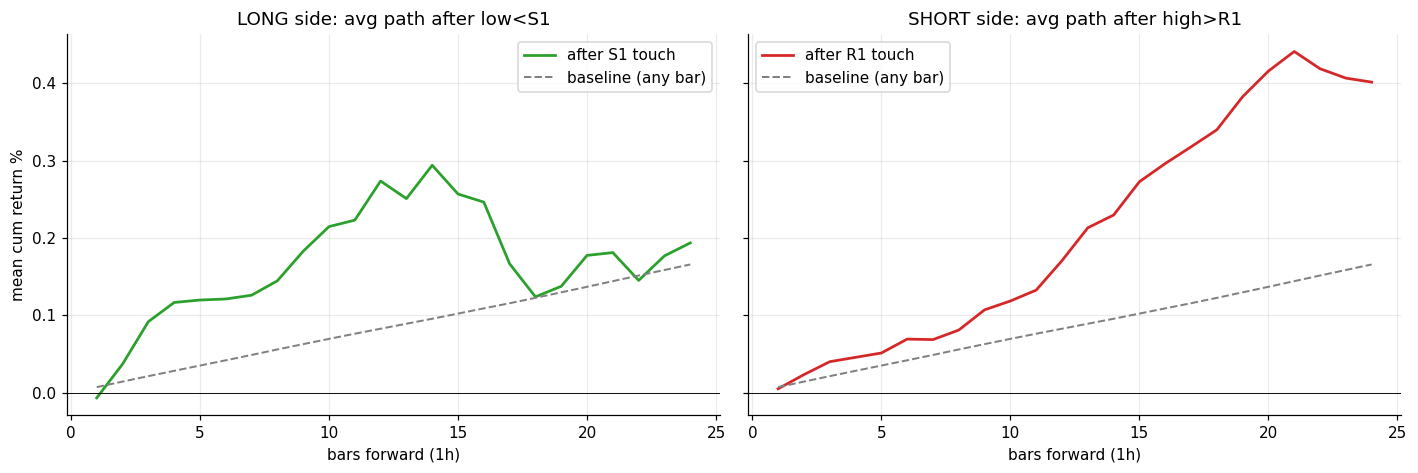

In [4]:
# ---- average forward path: touch vs baseline -------------------------------
hs = np.arange(1, H + 1)
fig, (axL, axS) = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)

axL.plot(hs, np.nanmean(long_paths, axis=0) * 100, color="#2ca02c", lw=1.8, label="after S1 touch")
axL.plot(hs, np.nanmean(base_paths, axis=0) * 100, color="gray", lw=1.3, ls="--", label="baseline (any bar)")
axL.axhline(0, color="k", lw=0.6)
axL.set_title("LONG side: avg path after low<S1")
axL.set_xlabel("bars forward (1h)"); axL.set_ylabel("mean cum return %"); axL.legend()

axS.plot(hs, np.nanmean(short_paths, axis=0) * 100, color="#d62728", lw=1.8, label="after R1 touch")
axS.plot(hs, np.nanmean(base_paths, axis=0) * 100, color="gray", lw=1.3, ls="--", label="baseline (any bar)")
axS.axhline(0, color="k", lw=0.6)
axS.set_title("SHORT side: avg path after high>R1")
axS.set_xlabel("bars forward (1h)"); axS.legend()
show("02_touch_paths")

## Verdict — H1 partly alive on the LONG side, dead on the SHORT side; prediction confirmed

**The two sides are asymmetric, exactly as predicted.** After *both* an S1 touch and an R1 touch, price on average **rises** — because pooled alts drift up (the gray baseline climbs to +0.17% @ h24). So the touch direction doesn't flip the drift; it only shifts the level:

- **LONG (low<S1): a real but small dip-buy edge.** The green path sits *above* baseline from h≈2 on, peaks around **+0.29% @ h13–14**, then fades back toward baseline by h18. Edge over baseline is best at h12 (**+0.19% gross**), and it **clears the 0.15% cost** in the h12–24 band (net +0.12% @ h12, +0.04% @ h24) but not at short horizons (net ≈0 or negative at h4/h8). Win-rate barely above 51% — this is a **mean/skew** edge, not a hit-rate edge.
- **SHORT (high>R1): refuted, and an anti-signal.** After touching R1 price keeps climbing *faster* than baseline (red line well above gray). Shorting it fights the alt up-drift AND a continuation push → short PnL negative and **worsening with horizon** (net −0.20% @h4 → −0.55% @h24). This is the same shape the `rsi` line found: overbought→short is a universal loser on 2024 alts.

**Is the long edge pivot-specific? Almost certainly not — yet.** The trigger `low<S1` is by construction 'price fell ~3% below the daily fair value' (headroom to P at entry = **+3.1%** median). That is just a **dip**, and the size of the dip is the S1 offset. The +0.12% net long edge is squarely in the range the `dump`/`rsi` lines already attribute to plain magnitude mean-reversion. We have **not** shown that touching *this formula's* level beats touching *any* level the same distance below price.

**Honest caveats.** 2024 only; entry at trigger-bar close (1-bar-delay check pending); overlapping/autocorrelated events within a symbol; flat 0.15% cost proxy; alt up-drift dominates the picture (a single-regime effect).

**Next step → `03` (the decisive control).** Matched-magnitude head-to-head, mirroring `rsi/03`: compare `low<S1` against a plain `drop of the same % below a rolling mean` (same dispersion, no pivot). If the pivot line adds nothing over a size-matched dip, H1 collapses to 'magnitude, owned by `dump`' and the 1.22 must live in the filters (H2–H4) — most likely the EMA200 trend gate turning this into a regime bet. If the pivot touch beats the matched dip, we have a genuine pivot phenomenon to keep building on.